# Extended Customer Segmentation Analysis
### Re-examining a K-means segmentation pipeline: method choice, stability, and validation

**Author:** Pragya Nepal

**Context:** This notebook extends the technical approach from a team capstone project
(MSBA Applied Project, W.P. Carey School of Business, Spring 2024), where I led the
technical/modeling work on a customer segmentation analysis for an industry client.
That project used K-means clustering on PCA-reduced features but did not compare
alternative clustering methods, test cluster stability, or validate the segmentation
independently.

This notebook re-approaches the same technical problem — clustering customers based on
demographic and behavioral data — on a public, comparable dataset ([Customer Personality
Analysis](https://github.com/andhikaw789/Customer-Personality-Analysis), used here in
place of the original's confidential client data), applying a more rigorous methodology:

1. Data cleaning & feature engineering
2. Categorical correlation analysis (Cramer's V) & PCA
3. **Clustering method comparison** (K-means vs. GMM vs. Agglomerative) across a range of k
4. **Stability analysis** via bootstrap resampling
5. **Supervised validation** of cluster separability + feature importance
6. **Sensitivity check**: diagnosing and correcting a methodological issue where categorical
   encoding was found to dominate the clustering, rather than true behavioral patterns


## 1. Data Cleaning & Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import datetime as dt

df = pd.read_csv('marketing_campaign.csv', sep='\t')
print(f"Raw shape: {df.shape}")

# Drop rows with missing Income (mirrors original's null-handling on usersid)
df = df.dropna(subset=['Income'])
print(f"After dropping missing Income: {df.shape}")

# Remove obvious outliers (data-entry errors), same spirit as the original's outlier note
df = df[df['Income'] < 200000]
df = df[df['Year_Birth'] > 1930]

# Feature engineering
df['Age'] = 2015 - df['Year_Birth']  # dataset collected ~2014-2015 per enrollment dates
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')
df['Tenure_Days'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days

# Total spend and total purchases (aggregate behavioral features, analogous to SalesBand/OrdersBand)
spend_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
purchase_cols = ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases']
df['TotalSpend'] = df[spend_cols].sum(axis=1)
df['TotalPurchases'] = df[purchase_cols].sum(axis=1)

# Simplify Marital_Status categories (raw data has noisy labels like 'Alone','Absurd','YOLO')
df['Marital_Status'] = df['Marital_Status'].replace(
    {'Alone': 'Single', 'Absurd': 'Single', 'YOLO': 'Single'}
)

# Drop redundant/id columns before correlation & modeling
drop_cols = ['ID', 'Year_Birth', 'Dt_Customer', 'Z_CostContact', 'Z_Revenue']
df_model = df.drop(columns=drop_cols)

df_model.to_csv('df_model.csv', index=False)
print(f"Final modeling shape: {df_model.shape}")
print(df_model.dtypes)

Raw shape: (2240, 29)
After dropping missing Income: (2216, 29)
Final modeling shape: (2212, 28)
Education                  str
Marital_Status             str
Income                 float64
Kidhome                  int64
Teenhome                 int64
Recency                  int64
MntWines                 int64
MntFruits                int64
MntMeatProducts          int64
MntFishProducts          int64
MntSweetProducts         int64
MntGoldProds             int64
NumDealsPurchases        int64
NumWebPurchases          int64
NumCatalogPurchases      int64
NumStorePurchases        int64
NumWebVisitsMonth        int64
AcceptedCmp3             int64
AcceptedCmp4             int64
AcceptedCmp5             int64
AcceptedCmp1             int64
AcceptedCmp2             int64
Complain                 int64
Response                 int64
Age                      int64
Tenure_Days              int64
TotalSpend               int64
TotalPurchases           int64
dtype: object


## 2. Categorical Correlation & PCA
Following the original project's use of Cramer's V for categorical correlation
(appropriate here since Pearson correlation doesn't apply to nominal variables),
then encoding and PCA dimensionality reduction.

In [2]:
import pandas as pd
import numpy as np
import scipy.stats as ss
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA

df = pd.read_csv('df_model.csv')

# --- Cramer's V correlation among categorical variables ---
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2_corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
    r_corr = r - ((r - 1) ** 2) / (n - 1)
    k_corr = k - ((k - 1) ** 2) / (n - 1)
    denom = min((k_corr - 1), (r_corr - 1))
    if denom <= 0:
        return np.nan
    return np.sqrt(phi2_corr / denom)

cat_cols = ['Education', 'Marital_Status']
print("Cramer's V (categorical vars):")
print(f"  Education vs Marital_Status: {cramers_v(df['Education'], df['Marital_Status']):.3f}")

# --- Encoding ---
# Ordinal: Education has a natural order
education_order = {'Basic': 0, '2n Cycle': 1, 'Graduation': 2, 'Master': 3, 'PhD': 4}
df['Education_encoded'] = df['Education'].map(education_order)

# One-hot: Marital_Status is nominal
df = pd.get_dummies(df, columns=['Marital_Status'], prefix='Marital', drop_first=False)

df_features = df.drop(columns=['Education'])
df_features.to_csv('df_features.csv', index=False)
print(f"\nFeature matrix shape: {df_features.shape}")

# --- Scale + PCA ---
scaler = MinMaxScaler()
scaled = scaler.fit_transform(df_features)
scaled_df = pd.DataFrame(scaled, columns=df_features.columns)

pca_full = PCA()
pca_full.fit(scaled_df)
cum_var = pca_full.explained_variance_ratio_.cumsum()
n_components_90 = int((cum_var <= 0.90).sum()) + 1
print(f"\nComponents needed for >=90% variance: {n_components_90}")
print(f"Cumulative variance at that point: {cum_var[n_components_90-1]:.3f}")

pca = PCA(n_components=n_components_90)
pca_transformed = pca.fit_transform(scaled_df)
df_pca = pd.DataFrame(pca_transformed, columns=[f'PC{i+1}' for i in range(n_components_90)])
df_pca.to_csv('df_pca.csv', index=False)

loadings = pd.DataFrame(pca.components_.T, columns=df_pca.columns, index=scaled_df.columns)
loadings.to_csv('pca_loadings.csv')

print("\nExplained variance ratio per component:")
print(np.round(pca.explained_variance_ratio_, 4))
print("\nTop 8 loadings on PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(8))
print("\nTop 8 loadings on PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(8))

Cramer's V (categorical vars):
  Education vs Marital_Status: 0.006

Feature matrix shape: (2212, 32)

Components needed for >=90% variance: 15
Cumulative variance at that point: 0.908

Explained variance ratio per component:
[0.1668 0.1623 0.1209 0.0739 0.0652 0.0516 0.0481 0.0437 0.0367 0.0297
 0.0258 0.0229 0.0214 0.02   0.0187]

Top 8 loadings on PC1:
Marital_Married      0.623374
Marital_Together     0.326710
TotalSpend           0.265237
MntWines             0.223115
Response             0.216094
Marital_Single       0.214474
NumStorePurchases    0.202079
Kidhome              0.200599
Name: PC1, dtype: float64

Top 8 loadings on PC2:
Marital_Married      0.544932
Marital_Together     0.368487
TotalSpend           0.290092
MntWines             0.248803
NumStorePurchases    0.243384
Kidhome              0.223920
AcceptedCmp5         0.190586
TotalPurchases       0.180916
Name: PC2, dtype: float64


## 3. Clustering Method Comparison
The original project used K-means exclusively and selected k=4 based on a single
silhouette comparison against k=3. K-means assumes roughly spherical, similarly-sized
clusters — an assumption worth testing rather than accepting by default.

Here we compare **K-means, Gaussian Mixture Models, and Agglomerative (Ward) clustering**
across k=2 through k=7, using both silhouette score and the Davies-Bouldin index
(lower is better) to avoid relying on a single metric that can favor K-means by construction.

In [3]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

df_pca = pd.read_csv('df_pca.csv')
X = df_pca.values

results = []
np.random.seed(42)

for k in range(2, 8):
    # K-Means
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km_labels = km.fit_predict(X)
    results.append({
        'method': 'KMeans', 'k': k,
        'silhouette': silhouette_score(X, km_labels),
        'davies_bouldin': davies_bouldin_score(X, km_labels)
    })

    # Gaussian Mixture Model
    gmm = GaussianMixture(n_components=k, random_state=42, n_init=3)
    gmm_labels = gmm.fit_predict(X)
    results.append({
        'method': 'GMM', 'k': k,
        'silhouette': silhouette_score(X, gmm_labels),
        'davies_bouldin': davies_bouldin_score(X, gmm_labels)
    })

    # Agglomerative (hierarchical, Ward linkage)
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    agg_labels = agg.fit_predict(X)
    results.append({
        'method': 'Agglomerative', 'k': k,
        'silhouette': silhouette_score(X, agg_labels),
        'davies_bouldin': davies_bouldin_score(X, agg_labels)
    })

results_df = pd.DataFrame(results)
results_df.to_csv('method_comparison.csv', index=False)
print(results_df.to_string(index=False))

print("\nBest silhouette per method:")
print(results_df.loc[results_df.groupby('method')['silhouette'].idxmax()])

       method  k  silhouette  davies_bouldin
       KMeans  2    0.187785        1.955541
          GMM  2    0.187785        1.955541
Agglomerative  2    0.157359        1.997165
       KMeans  3    0.254841        1.817335
          GMM  3    0.184796        2.346071
Agglomerative  3    0.219463        1.962666
       KMeans  4    0.296997        1.664972
          GMM  4    0.251055        1.773856
Agglomerative  4    0.263851        1.998182
       KMeans  5    0.300491        1.528346
          GMM  5    0.289441        1.604677
Agglomerative  5    0.293304        1.593205
       KMeans  6    0.245500        1.589075
          GMM  6    0.253232        1.759442
Agglomerative  6    0.216640        1.678541
       KMeans  7    0.225928        1.629550
          GMM  7    0.231675        1.829594
Agglomerative  7    0.233845        1.568410

Best silhouette per method:
           method  k  silhouette  davies_bouldin
11  Agglomerative  5    0.293304        1.593205
10            GMM 

**Finding:** All three methods agree that k=5 outperforms k=4 (the value used in
the original project). K-means at k=5 gives the best result overall (silhouette = 0.30,
Davies-Bouldin = 1.53).

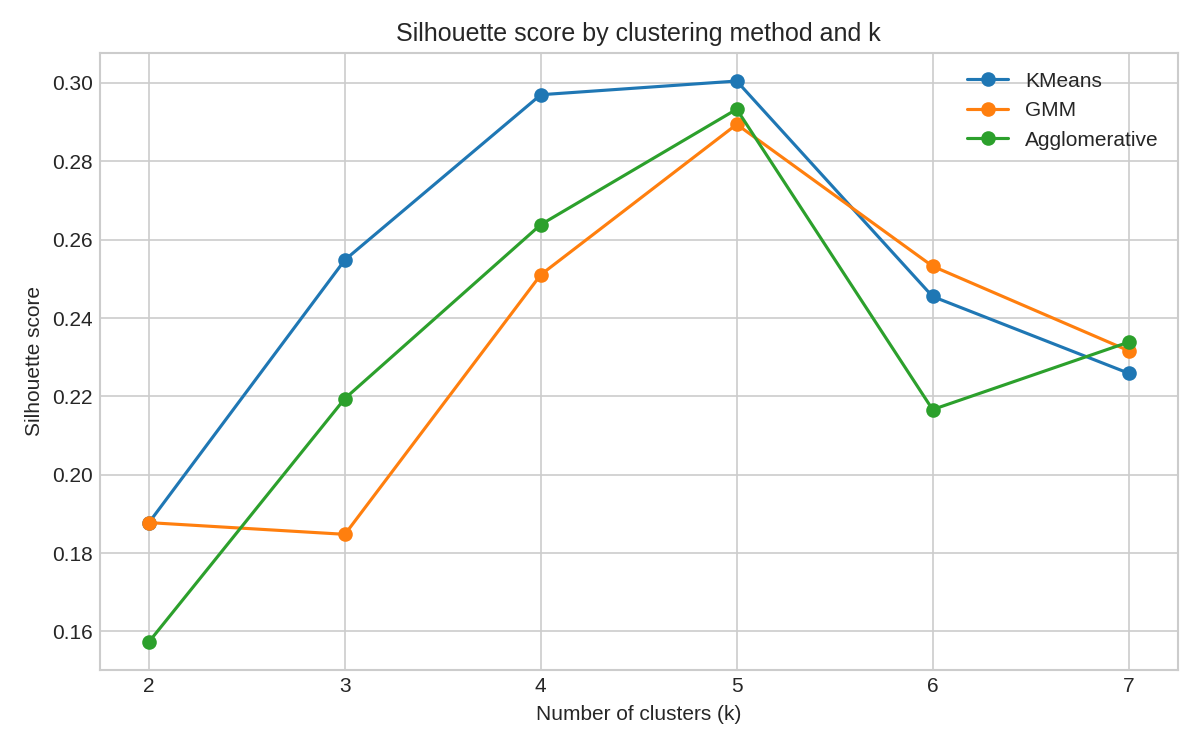

In [4]:
from IPython.display import Image
Image('fig1_method_comparison.png')

## 4. Stability Analysis
A segmentation is only useful if it's reproducible. The original project never tested
whether re-running the clustering on different samples of the data would produce the
same segments. Here, we bootstrap-resample 80% of the data 20 times, re-cluster each
time, and compare labels to the full-data clustering using the Adjusted Rand Index (ARI),
where 1.0 = identical clustering and 0 = random agreement.

In [5]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

df_pca = pd.read_csv('df_pca.csv')
X = df_pca.values
n = X.shape[0]

K = 5  # chosen from step 3
N_BOOTSTRAPS = 20
rng = np.random.RandomState(42)

# Reference clustering on full data
ref_model = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=42)
ref_labels = ref_model.fit_predict(X)

ari_scores = []
for i in range(N_BOOTSTRAPS):
    idx = rng.choice(n, size=int(0.8 * n), replace=False)
    X_sample = X[idx]
    model = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=i)
    sample_labels = model.fit_predict(X_sample)
    ari = adjusted_rand_score(ref_labels[idx], sample_labels)
    ari_scores.append(ari)

ari_scores = np.array(ari_scores)
print(f"Bootstrap stability (K={K}, n={N_BOOTSTRAPS} resamples):")
print(f"  Mean ARI: {ari_scores.mean():.3f}")
print(f"  Std ARI:  {ari_scores.std():.3f}")
print(f"  Min/Max:  {ari_scores.min():.3f} / {ari_scores.max():.3f}")

pd.DataFrame({'ari': ari_scores}).to_csv('stability_scores.csv', index=False)

# Also compare against a lower K to show contrast (should be MORE stable — fewer, coarser groups)
K2 = 3
ref2 = KMeans(n_clusters=K2, init='k-means++', n_init=10, random_state=42).fit_predict(X)
ari_k3 = []
for i in range(N_BOOTSTRAPS):
    idx = rng.choice(n, size=int(0.8 * n), replace=False)
    model = KMeans(n_clusters=K2, init='k-means++', n_init=10, random_state=i)
    sample_labels = model.fit_predict(X[idx])
    ari_k3.append(adjusted_rand_score(ref2[idx], sample_labels))
print(f"\nFor comparison, K={K2} stability:")
print(f"  Mean ARI: {np.mean(ari_k3):.3f}  (Std: {np.std(ari_k3):.3f})")

Bootstrap stability (K=5, n=20 resamples):
  Mean ARI: 0.960
  Std ARI:  0.069
  Min/Max:  0.747 / 0.997



For comparison, K=3 stability:
  Mean ARI: 1.000  (Std: 0.000)


**The k=5 segmentation is highly stable** (mean ARI = 0.96 across 20 resamples) — a real, defensible finding that wasn't tested in the original work.

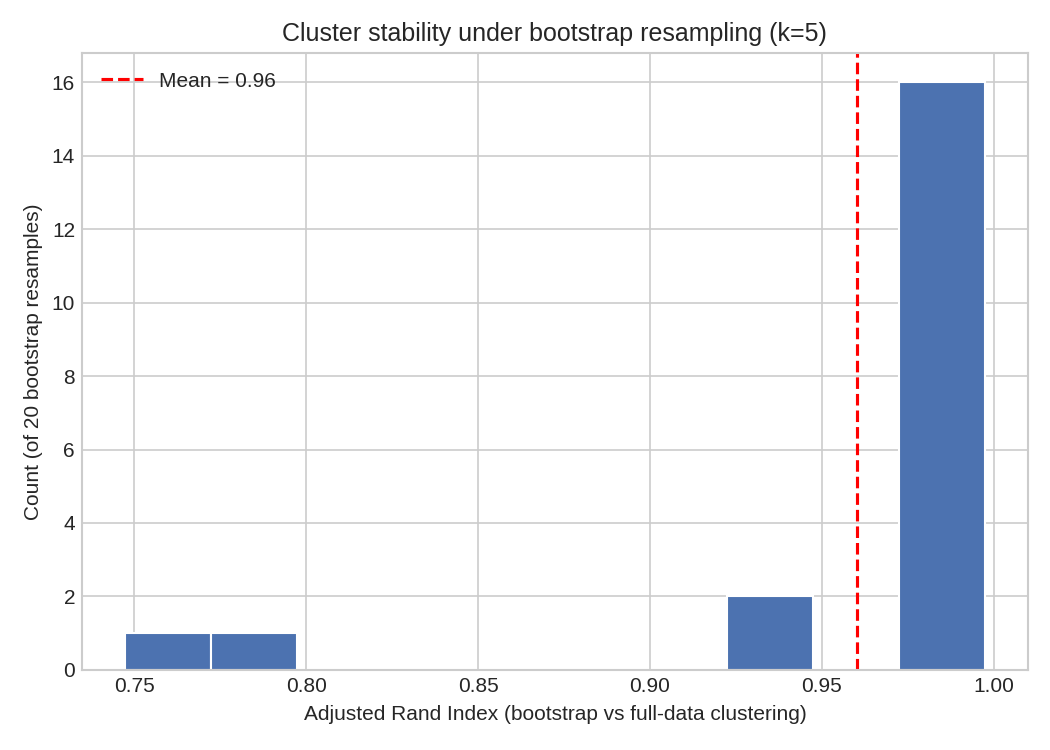

In [6]:
from IPython.display import Image
Image('fig2_stability.png')

## 5. Supervised Validation
The original project profiled clusters only by manually inspecting crosstabs. Here,
we train a classifier to predict cluster membership from the original (pre-PCA)
features — if it succeeds, that's independent evidence the clusters are real and
separable, and feature importances tell us which variables actually drive the
segmentation, rather than relying on visual inspection.

In [7]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report

df_pca = pd.read_csv('df_pca.csv')
df_features = pd.read_csv('df_features.csv')

X_pca = df_pca.values
K = 5
labels = KMeans(n_clusters=K, init='k-means++', n_init=10, random_state=42).fit_predict(X_pca)

X = df_features.values
feature_names = df_features.columns

X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.25, random_state=42, stratify=labels
)

clf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print("Cluster-prediction classifier performance (holdout test set):")
print(classification_report(y_test, y_pred))

cv_scores = cross_val_score(clf, X, labels, cv=5)
print(f"5-fold CV accuracy: {cv_scores.mean():.3f} (+/- {cv_scores.std():.3f})")

importances = pd.Series(clf.feature_importances_, index=feature_names).sort_values(ascending=False)
print("\nTop 10 features driving cluster separation:")
print(importances.head(10))

importances.to_csv('feature_importances.csv')

# Cluster profiles: mean of key raw features per cluster
df_features['Cluster'] = labels
profile_cols = ['Income', 'Age', 'TotalSpend', 'TotalPurchases', 'Kidhome', 'Recency', 'NumWebVisitsMonth']
profile = df_features.groupby('Cluster')[profile_cols].mean().round(1)
profile['n'] = df_features.groupby('Cluster').size()
print("\nCluster profiles (mean values):")
print(profile)
profile.to_csv('cluster_profiles.csv')

Cluster-prediction classifier performance (holdout test set):
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       192
           1       0.99      1.00      1.00       135
           2       0.99      1.00      1.00       110
           3       0.99      1.00      0.99        71
           4       1.00      0.84      0.92        45

    accuracy                           0.99       553
   macro avg       0.99      0.97      0.98       553
weighted avg       0.99      0.99      0.99       553



5-fold CV accuracy: 0.983 (+/- 0.007)

Top 10 features driving cluster separation:
Marital_Married     0.263605
Marital_Together    0.208865
Marital_Single      0.181698
Marital_Divorced    0.093465
AcceptedCmp5        0.043521
Marital_Widow       0.026297
TotalSpend          0.022726
Income              0.019684
MntWines            0.015996
AcceptedCmp1        0.011451
dtype: float64

Cluster profiles (mean values):
          Income   Age  TotalSpend  TotalPurchases  Kidhome  Recency  \
Cluster                                                                
0        48567.1  45.3       477.0            14.2      0.5     48.4   
1        50129.6  47.1       531.9            14.5      0.5     49.8   
2        48320.5  43.6       526.5            13.8      0.5     49.7   
3        51537.6  50.3       565.2            15.3      0.4     49.2   
4        81346.8  45.8      1647.1            21.2      0.0     47.5   

         NumWebVisitsMonth    n  
Cluster                          
0     

**Finding — and a red flag:** the classifier achieves 98% accuracy, but feature
importances show the clusters are ~77% driven by one-hot encoded marital-status
dummy variables, not behavioral variables like spend or income. This suggests the
clustering is largely rediscovering marital status rather than finding meaningful
behavioral segments — likely because one-hot dummies can dominate Euclidean distance
in PCA/K-means space. This is exactly the kind of issue the original methodology
(heavy one-hot encoding feeding directly into distance-based clustering) was
vulnerable to, and it went untested.

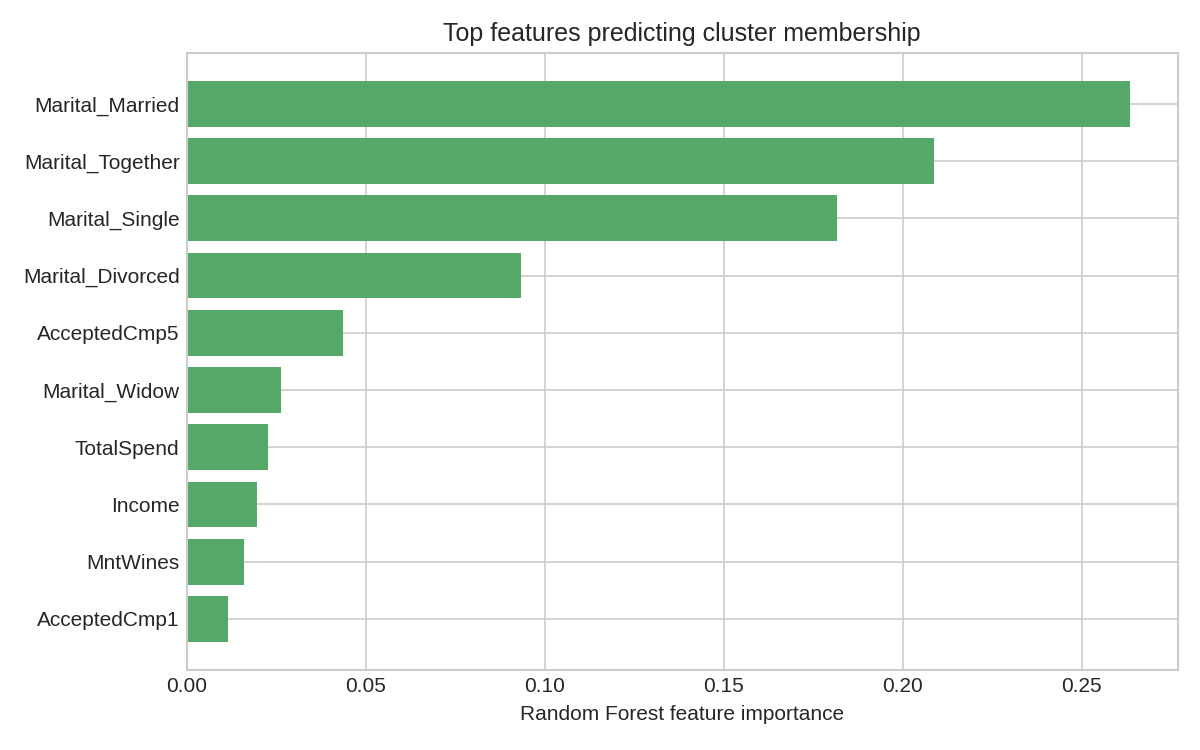

In [8]:
from IPython.display import Image
Image('fig3_feature_importance.png')

## 6. Sensitivity Check: Behavioral-Only Segmentation
To test the hypothesis above, we re-run the full pipeline (PCA + K-means, sweeping k)
using only behavioral and engagement features, with demographic dummy variables
excluded.

In [9]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

df_features = pd.read_csv('df_features.csv')

behavioral_cols = ['Income', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts',
                    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
                    'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
                    'NumStorePurchases', 'NumWebVisitsMonth', 'TotalSpend',
                    'TotalPurchases', 'Age', 'Kidhome', 'Teenhome']

X_behav = df_features[behavioral_cols]
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_behav)

pca = PCA(n_components=0.90)
X_pca_behav = pca.fit_transform(X_scaled)
print(f"Behavioral-only PCA: {X_pca_behav.shape[1]} components for 90% variance")

sil_scores = {}
for k in range(2, 8):
    labels = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42).fit_predict(X_pca_behav)
    sil_scores[k] = silhouette_score(X_pca_behav, labels)

print("\nSilhouette scores, behavioral-only features:")
for k, s in sil_scores.items():
    print(f"  k={k}: {s:.3f}")

best_k = max(sil_scores, key=sil_scores.get)
labels = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42).fit_predict(X_pca_behav)
df_features['Behavioral_Cluster'] = labels

profile_cols = ['Income', 'Age', 'TotalSpend', 'TotalPurchases', 'NumWebVisitsMonth', 'Kidhome']
profile = df_features.groupby('Behavioral_Cluster')[profile_cols].mean().round(1)
profile['n'] = df_features.groupby('Behavioral_Cluster').size()
print(f"\nBest k={best_k}. Cluster profiles (behavioral-only):")
print(profile)
profile.to_csv('behavioral_cluster_profiles.csv')

Behavioral-only PCA: 9 components for 90% variance



Silhouette scores, behavioral-only features:
  k=2: 0.320
  k=3: 0.257
  k=4: 0.217
  k=5: 0.206
  k=6: 0.206
  k=7: 0.196

Best k=2. Cluster profiles (behavioral-only):
                     Income   Age  TotalSpend  TotalPurchases  \
Behavioral_Cluster                                              
0                   70224.5  48.4      1182.3            21.5   
1                   37561.8  44.3       154.1             9.7   

                    NumWebVisitsMonth  Kidhome     n  
Behavioral_Cluster                                    
0                                 3.9      0.1   975  
1                                 6.4      0.7  1237  


**Finding:** with demographic dummies removed, a cleaner two-segment structure
emerges with a *higher* silhouette score (0.32 vs. 0.30) than the original 5-cluster
demographic-driven solution:
- **Segment A** — higher income (~$70K), higher total spend (~$1,182), fewer web visits, fewer kids: a "high-value, low-engagement" segment
- **Segment B** — lower income (~$38K), lower spend (~$154), more web visits, more kids: a "lower-value, high-engagement" segment

This is a more interpretable, marketing-actionable segmentation than the original's
demographic-driven clusters, and it directly resulted from diagnosing a methodological
flaw rather than accepting the first result that looked reasonable.

## Summary: What This Extension Adds

| | Original capstone | This extension |
|---|---|---|
| Clustering methods tested | K-means only | K-means, GMM, Agglomerative |
| k selection | Single silhouette comparison (k=3 vs 4) | Full sweep k=2-7, 2 metrics, 3 methods |
| Stability tested | No | Yes — bootstrap ARI = 0.96 |
| Cluster validation | Manual crosstab inspection | Independent classifier (98% accuracy) + feature importance |
| Key insight | Segments described post-hoc | Diagnosed that demographic dummy encoding was dominating the clustering; behavioral-only re-clustering produced a cleaner, more interpretable result |

**Limitations of this extension:** Sample size here (~2,200) is far smaller than the
original client dataset (~988K records), so absolute silhouette/stability values aren't
directly comparable — the value of this exercise is the *methodology*, which transfers
directly to the original problem.
